In [2]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax
from jaxtyping import Float, Int, Array, Complex, Num
from jax.numpy.fft import fft, ifft
Float2D = Float[Array, "x1 x2"]
Complex1D = Complex[Array, "x1"]
Array1D = Num[Array, "x1"]

97.35861048843343
0.0061321863721865


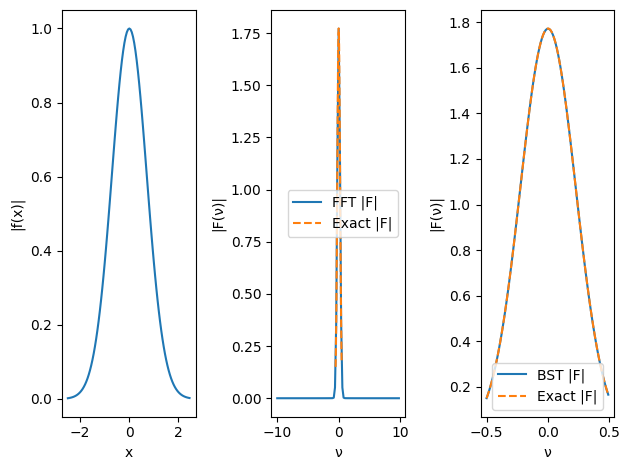

In [20]:
from bst.bst import generate_bst
jax.config.update("jax_enable_x64", True)
Lx = 5
Lf = 0.5
N = 100
x = np.linspace(-Lx / 2, Lx / 2, N, endpoint=False)
dx = x[1] - x[0]
nu = np.linspace(-Lf, Lf, N, endpoint=False)
y = jnp.exp(-x**2)

Y = generate_bst(x, nu)(y)
print(np.sum(np.abs(np.real(Y))))
print(np.sum(np.abs(np.imag(Y))))

F = jnp.fft.fftshift(jnp.fft.fft(y))
mu = jnp.fft.fftshift(jnp.fft.fftfreq(N, x[1] - x[0]))

F_exact = np.sqrt(np.pi) * np.exp(-(np.pi * nu)**2)

fig, ax = plt.subplots(1, 3)

ax[0].plot(x, y)
ax[0].set_xlabel("x")
ax[0].set_ylabel("|f(x)|")

ax[1].plot(mu, dx * np.abs(F), label="FFT |F|")
ax[1].plot(nu, np.abs(F_exact), "--", label="Exact |F|")
ax[1].legend()
ax[1].set_xlabel("ν")
ax[1].set_ylabel("|F(ν)|")

ax[2].plot(nu, np.abs(Y), label="BST |F|")
ax[2].plot(nu, np.abs(F_exact), "--", label="Exact |F|")
ax[2].legend()
ax[2].set_xlabel("ν")
ax[2].set_ylabel("|F(ν)|")

plt.tight_layout()
plt.show()

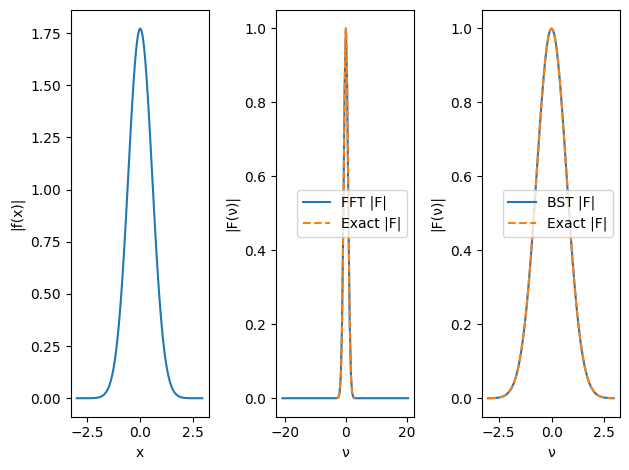

In [28]:
from bst.bst import ibst
import jax
import numpy as np
from matplotlib import pyplot as plt
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)
Lx = 6
Lf = 1.2
N = 100
x = np.linspace(-Lx / 2, Lx / 2, N, endpoint=False)
dx = x[1] - x[0]
nu = np.linspace(-Lf, Lf, N, endpoint=False)
dnu = nu[1] - nu[0]
f_exact = jnp.exp(-x**2)
F = np.sqrt(np.pi) * np.exp(-(np.pi * nu)**2)

f_ibst = ibst(nu, x, F)


x_ifft = jnp.fft.ifftshift(jnp.fft.fftfreq(N, nu[1] - nu[0]))
f_ifft = (1 / (x_ifft[1] - x_ifft[0])) * jnp.fft.ifftshift(jnp.fft.ifft(F))

fig, ax = plt.subplots(1, 3)

ax[0].plot(x, F)
ax[0].set_xlabel("x")
ax[0].set_ylabel("|f(x)|")

ax[1].plot(x_ifft, np.abs(f_ifft), label="FFT |F|")
ax[1].plot(x, np.abs(f_exact), "--", label="Exact |F|")
ax[1].legend()
ax[1].set_xlabel("ν")
ax[1].set_ylabel("|F(ν)|")

ax[2].plot(x, np.abs(f_ibst), label="BST |F|")
ax[2].plot(x, np.abs(f_exact), "--", label="Exact |F|")
ax[2].legend()
ax[2].set_xlabel("ν")
ax[2].set_ylabel("|F(ν)|")

plt.tight_layout()
plt.show()

50000.00000000001
0.0


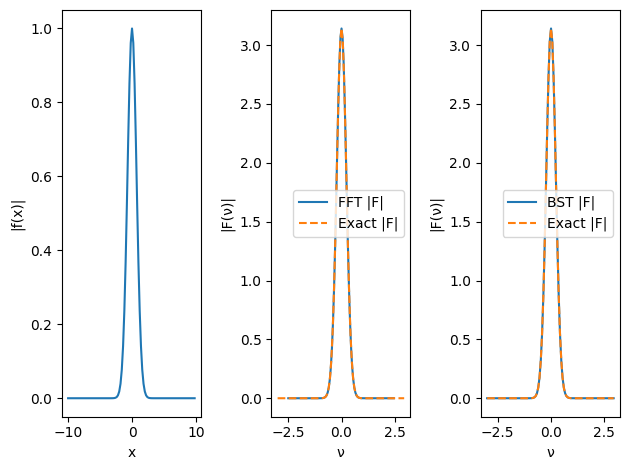

In [21]:
from bst.bst import generate_bst, generate_bst2D
jax.config.update("jax_enable_x64", True)
Lx = 10
Lf = 15
N = 100
x = np.linspace(-10, 10, 100, endpoint=False)
y = x
dx = x[1] - x[0]
nu_x = np.linspace(-3, 3, 100, endpoint=False)
nu_y = nu_x
nu_X, nu_Y = np.meshgrid(nu_x, nu_y)

X, Y = np.meshgrid(x, y)

f = jnp.exp(-(X**2 + Y**2))

F = generate_bst2D(x, y, nu_x, nu_y)(f)


print(np.sum(np.abs(np.real(Y))))
print(np.sum(np.abs(np.imag(Y))))

FFT = jnp.fft.fftshift(jnp.fft.fft2(f))
mu_x = jnp.fft.fftshift(jnp.fft.fftfreq(N, x[1] - x[0]))
mu_y = mu_x

F_exact = np.pi * np.exp(-np.pi**2 * (nu_X**2 + nu_Y**2))

fig, ax = plt.subplots(1, 3)

midpoint = len(f) // 2

ax[0].plot(x, f[midpoint])
ax[0].set_xlabel("x")
ax[0].set_ylabel("|f(x)|")

ax[1].plot(mu_x, dx**2 * np.abs(FFT[midpoint]), label="FFT |F|")
ax[1].plot(nu_x, np.abs(F_exact[midpoint]), "--", label="Exact |F|")
ax[1].legend()
ax[1].set_xlabel("ν")
ax[1].set_ylabel("|F(ν)|")

ax[2].plot(nu_x, np.abs(F[midpoint]), label="BST |F|")
ax[2].plot(nu_x, np.abs(F_exact[midpoint]), "--", label="Exact |F|")
ax[2].legend()
ax[2].set_xlabel("ν")
ax[2].set_ylabel("|F(ν)|")

plt.tight_layout()
plt.show()